<a href="https://colab.research.google.com/github/AlvaroAla/TE-IA/blob/main/aula5_visualizacao_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5: Embeddings com modelo *encoder-only* e visualização

Nesta prática você vai usar embeddings e verificar visualmente a intuição de que conceitos semânticos estão espacialmente próximos nos embeddings.

O roteiro é:

1. **Carregar um modelo *encoder-only* para embeddings**.
2. **Gerar embeddings por sentença** para uma coleção de documentos.
3. **Reduzir a dimensionalidade** e **plotar em 2D** para inspecionar agrupamentos.

---


## 0) Setup do ambiente

Vamos instalar dependências e importar bibliotecas.


In [1]:
# Se necessário, instale dependências (descomente e rode)
# !pip -q install -U sentence-transformers scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA

# Opcional: para separar sentenças de forma simples (sem libs pesadas)
import re


## 1) Mini-dataset
Vamos criar uma coleção pequena de documentos, com **rótulos de tópico** (categorias).
Você pode substituir por textos reais (artigos, notícias, parágrafos de PDFs, etc.).


In [2]:
docs = [
    {
        "id": "d1",
        "label": "esporte",
        "text": (
            "O time venceu por 2 a 1 no último minuto. "
            "O técnico elogiou a disciplina tática e a força do elenco. "
            "A torcida comemorou a classificação no estádio."
        )
    },
    {
        "id": "d2",
        "label": "esporte",
        "text": (
            "O campeonato começou com jogos equilibrados. "
            "O atacante marcou dois gols e foi o destaque da rodada. "
            "A equipe treinou finalizações durante a semana."
        )
    },
    {
        "id": "d3",
        "label": "economia",
        "text": (
            "A inflação desacelerou neste mês segundo o indicador oficial. "
            "O banco central sinalizou cautela na política monetária. "
            "O mercado reagiu com queda nos juros futuros."
        )
    },
    {
        "id": "d4",
        "label": "economia",
        "text": (
            "A taxa de câmbio variou após o anúncio do pacote fiscal. "
            "Analistas revisaram projeções de crescimento para o próximo ano. "
            "O consumo das famílias ainda mostra recuperação lenta."
        )
    },
    {
        "id": "d5",
        "label": "tecnologia",
        "text": (
            "Um novo modelo de linguagem foi lançado com foco em eficiência. "
            "Pesquisadores discutem alinhamento e segurança em IA. "
            "O treinamento usou dados em múltiplos idiomas usado em olimpíadas."
        )
    },
    {
        "id": "d6",
        "label": "tecnologia",
        "text": (
            "Sistemas de recomendação usam embeddings para medir similaridade. "
            "A compressão de modelos ajuda a reduzir custo de inferência. "
            "A comunidade debate benchmarks e avaliação justa."
        )
    },
]

df_docs = pd.DataFrame(docs)
df_docs


,id,label,text
0,d1,esporte,O time venceu por 2 a 1 no último minuto. O té...
1,d2,esporte,O campeonato começou com jogos equilibrados. O...
2,d3,economia,A inflação desacelerou neste mês segundo o ind...
3,d4,economia,A taxa de câmbio variou após o anúncio do paco...
4,d5,tecnologia,Um novo modelo de linguagem foi lançado com fo...
5,d6,tecnologia,Sistemas de recomendação usam embeddings para ...


## 2) Quebrar documentos em sentenças

Vamos transformar cada documento em várias sentenças.  
No final, teremos um dataframe com colunas: `doc_id`, `label`, `sentence`.


In [3]:
def split_sentences_pt(text: str) -> list[str]:
    # Split simples por ., !, ? mantendo robustez básica
    # Para produção, considere spaCy / nltk / blingfire, etc.
    parts = re.split(r'(?<=[\.!\?])\s+', text.strip())
    # Filtra vazios
    return [p.strip() for p in parts if p.strip()]

rows = []
for d in docs:
    for sent in split_sentences_pt(d["text"]):
        rows.append({"doc_id": d["id"], "label": d["label"], "sentence": sent})

df_sents = pd.DataFrame(rows)
df_sents


,doc_id,label,sentence
0,d1,esporte,O time venceu por 2 a 1 no último minuto.
1,d1,esporte,O técnico elogiou a disciplina tática e a forç...
2,d1,esporte,A torcida comemorou a classificação no estádio.
3,d2,esporte,O campeonato começou com jogos equilibrados.
4,d2,esporte,O atacante marcou dois gols e foi o destaque d...
5,d2,esporte,A equipe treinou finalizações durante a semana.
6,d3,economia,A inflação desacelerou neste mês segundo o ind...
7,d3,economia,O banco central sinalizou cautela na política ...
8,d3,economia,O mercado reagiu com queda nos juros futuros.
9,d4,economia,A taxa de câmbio variou após o anúncio do paco...


## 3) Carregar modelo *encoder-only* para embeddings

Para embeddings de sentença, é comum usar modelos já ajustados para similaridade semântica, como os da família **Sentence Transformers**.

Exemplos:
- `sentence-transformers/all-MiniLM-L6-v2` (inglês, ótimo custo/benefício)
- `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (multilíngue, bom para PT)

Aqui usaremos o multilíngue para funcionar bem em português.


In [4]:
from sentence_transformers import SentenceTransformer

# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

# Embedding de uma frase (teste rápido)
test_vec = model.encode(["Olá mundo!"])
test_vec.shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(1, 384)

## 4) Gerar embeddings para cada sentença

Vamos aplicar `model.encode` em lote (batch) para ser eficiente.


In [5]:
sentences = df_sents["sentence"].tolist()

# normalize_embeddings=True facilita visualização e similaridade por cosseno
emb = model.encode(
    sentences,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

emb.shape


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(18, 384)

Agora vamos guardar esses embeddings no dataframe (uma coluna com array).

In [6]:
df_sents = df_sents.copy()
df_sents["embedding"] = list(emb)
df_sents.head()


,doc_id,label,sentence,embedding
0,d1,esporte,O time venceu por 2 a 1 no último minuto.,"[-0.02810881, 0.01046761, -0.014270837, -0.007..."
1,d1,esporte,O técnico elogiou a disciplina tática e a forç...,"[-0.044420507, -0.013299455, -0.00060507277, -..."
2,d1,esporte,A torcida comemorou a classificação no estádio.,"[0.05787886, 0.040303282, -0.072480544, -0.067..."
3,d2,esporte,O campeonato começou com jogos equilibrados.,"[0.037911437, 0.016069286, -0.05541227, -0.037..."
4,d2,esporte,O atacante marcou dois gols e foi o destaque d...,"[0.0043280153, 0.034407362, -0.08520726, 0.015..."


## 5) Redução de dimensionalidade para 2D

Existem diferentes técnicas para reduzir dimensionalidade de embedding.
- **PCA** (linear, rápido; preserva variância global)
- **ICA** (linear, busca componentes estatisticamente independentes)
- **t-SNE** (não-linear, bom para estrutura local; ótimo para visualização)

Frequentemente usa-se **PCA antes do t-SNE** para reduzir a dimensionalidade original para 50 dimensões, o que ajuda em para acelerar o processo e reduzir ruído.

A seguir, vamos observar na prática como isso funciona.


In [7]:
X = np.vstack(df_sents["embedding"].to_numpy())  # (n_sentences, dim)

# 5.1) PCA direto para 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

# 5.2) ICA direto para 2D
ica2 = FastICA(n_components=2, random_state=42, max_iter=2000)
X_ica2 = ica2.fit_transform(X)

tsne2 = TSNE(
    n_components=2,
    perplexity=5,           # ajuste conforme o tamanho do dataset (tipicamente 5..50)
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_tsne2 = tsne2.fit_transform(X)

X_pca2.shape, X_ica2.shape, X_tsne2.shape


((18, 2), (18, 2), (18, 2))

## 6) Função de plot 2D (com cores por categoria)

Vamos plotar cada sentença como um ponto 2D.  
**Interpretação esperada:** sentenças do mesmo tópico tendem a ficar mais próximas, mas não é garantido (dataset pequeno!).


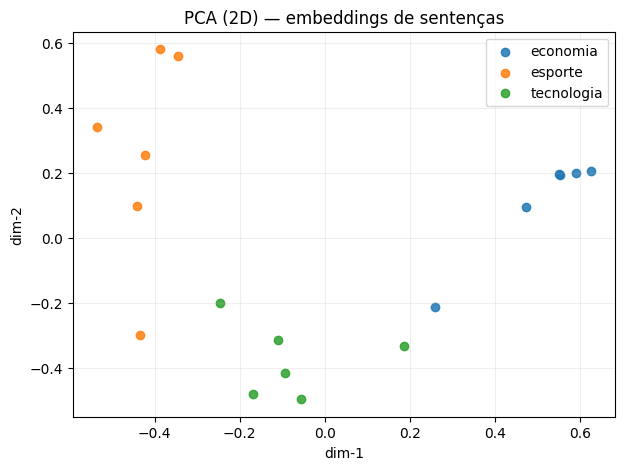

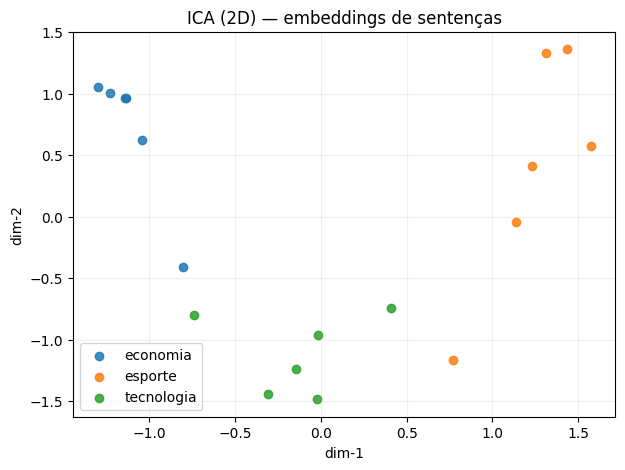

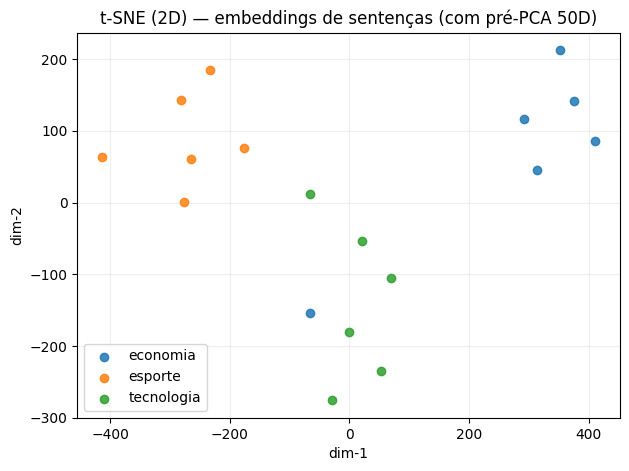

In [8]:
def plot_2d(X2, title: str, df_meta: pd.DataFrame):
    plt.figure(figsize=(7, 5))
    for label, sub in df_meta.groupby("label"):
        idx = sub.index.to_numpy()
        plt.scatter(X2[idx, 0], X2[idx, 1], label=label, alpha=0.85)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_2d(X_pca2, "PCA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_ica2, "ICA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_tsne2, "t-SNE (2D) — embeddings de sentenças (com pré-PCA 50D)", df_sents)


## 7) Embedding por documento (agregação)

Às vezes você quer um embedding **por documento**, não por sentença.  
Uma forma simples é fazer **média** dos embeddings das sentenças do documento (pode funcionar razoavelmente).

Depois, repita PCA/t-SNE para visualizar documentos.


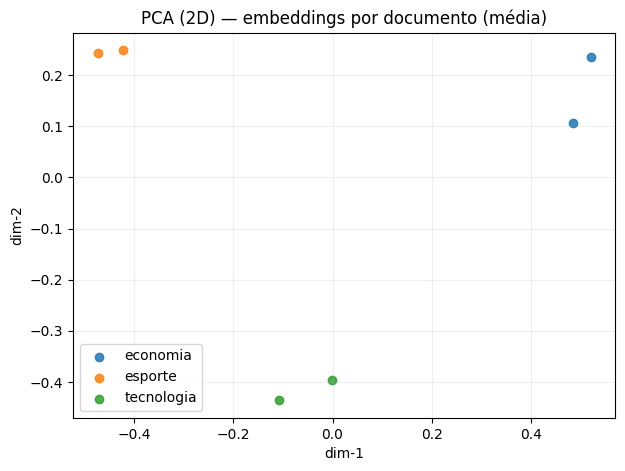

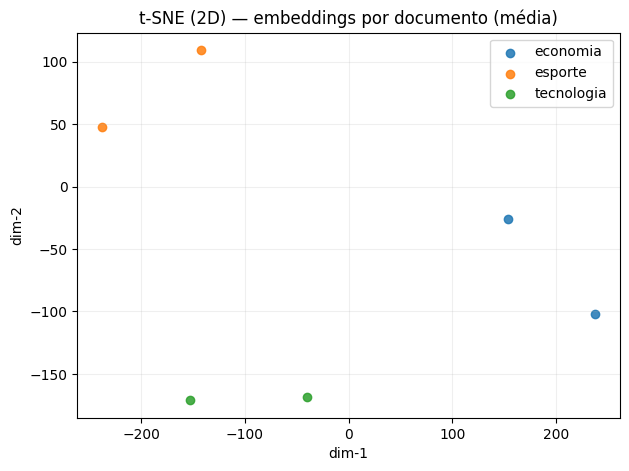

,doc_id,label
0,d1,esporte
1,d2,esporte
2,d3,economia
3,d4,economia
4,d5,tecnologia
5,d6,tecnologia


In [9]:
# Agrega por doc: média dos vetores das sentenças
df_doc_emb = (
    df_sents
    .groupby(["doc_id", "label"])["embedding"]
    .apply(lambda vs: np.mean(np.vstack(vs), axis=0))
    .reset_index()
)

X_doc = np.vstack(df_doc_emb["embedding"].to_numpy())

# PCA 2D
X_doc_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_doc)

# t-SNE 2D (sem pré-PCA pois é pequeno)
X_doc_tsne2 = TSNE(
    n_components=2,
    perplexity=3,
    learning_rate="auto",
    init="random",
    random_state=42,
).fit_transform(X_doc)

plot_2d(X_doc_pca2, "PCA (2D) — embeddings por documento (média)", df_doc_emb)
plot_2d(X_doc_tsne2, "t-SNE (2D) — embeddings por documento (média)", df_doc_emb)

df_doc_emb[["doc_id", "label"]]


# Exercícios

## Exercício A — Substitua o dataset
1. Use outro dataset com **50 a 150 documentos**, com **3 a 5 tópicos** (ex.: política, saúde, cultura, tecnologia, esporte).
2. Quebre em sentenças.
3. Gere embeddings e visualize com PCA e t-SNE.
4. Escreva 3 observações:
   - Algum tópico formou cluster claro?
   - Há sentenças “fora do lugar”? Por quê?
   - O que muda ao trocar o modelo (inglês vs multilíngue)?

## Exercício B — Variações de t-SNE
1. Teste `perplexity` em {5, 10, 30}.
2. Teste `init` em {"pca", "random"}.
3. Compare estabilidade visual (semente fixa vs outra).

## Exercício C — PCA antes do t-SNE
1. Rode t-SNE com e sem PCA prévio (50D).
2. Compare tempo e qualidade da separação.

---


# Atividade – Embeddings com modelo encoder-only e visualização

Nesta atividade, o objetivo foi gerar **embeddings semânticos** com um modelo **encoder-only** e visualizar como sentenças e documentos semanticamente parecidos tendem a ficar mais próximos no espaço vetorial.

Para isso, foi utilizado um conjunto de documentos em português, organizados em três tópicos: **esporte**, **economia** e **tecnologia**. Cada documento foi dividido em sentenças, e para cada sentença foi gerado um embedding usando um modelo da família **Sentence Transformers**.

Depois, foram aplicadas técnicas de **redução de dimensionalidade** para projetar os embeddings em duas dimensões, permitindo a visualização em gráficos. As técnicas utilizadas foram:

- **PCA**, que preserva a variância global dos dados;
- **ICA**, que busca componentes independentes;
- **t-SNE**, que é mais voltado para visualização e preservação de vizinhança local.

Além da análise por sentença, também foi feito um embedding por documento, calculado como a **média dos embeddings das sentenças** de cada documento.

Com isso, foi possível observar visualmente a ideia de que textos com conteúdo parecido tendem a formar agrupamentos mais próximos.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

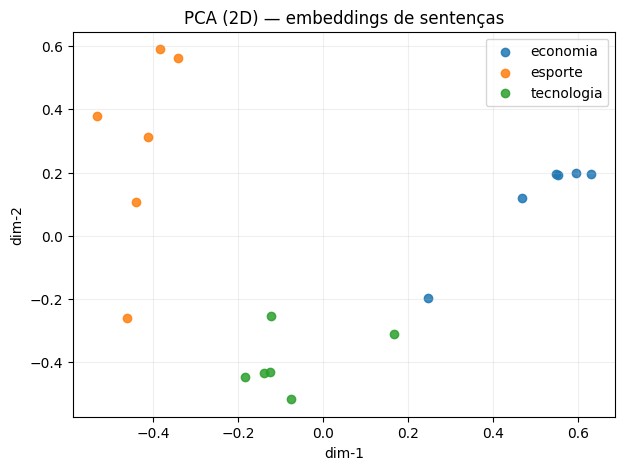

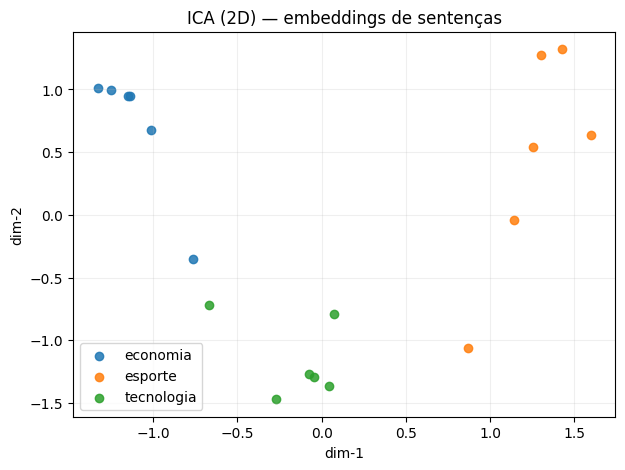

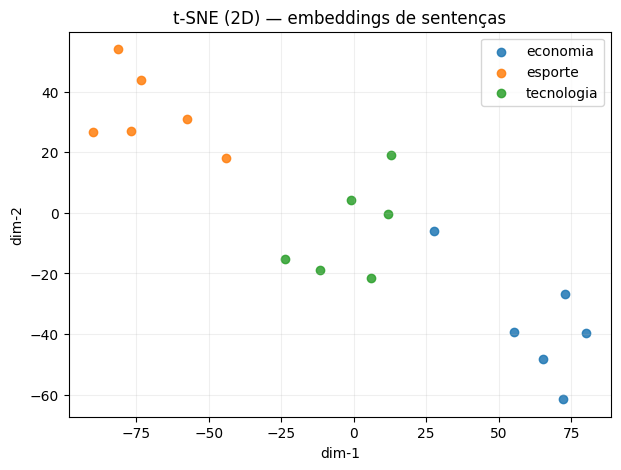

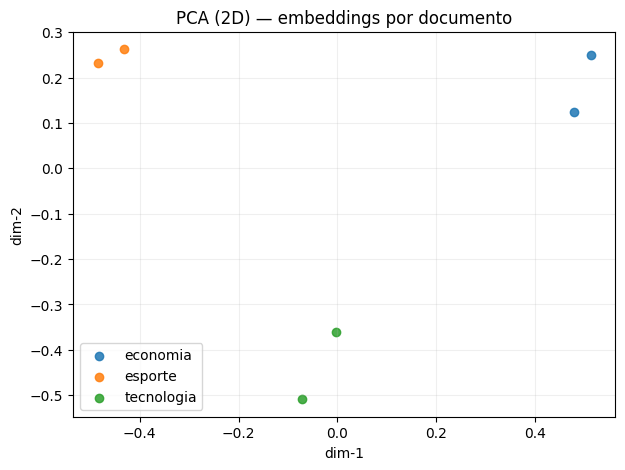

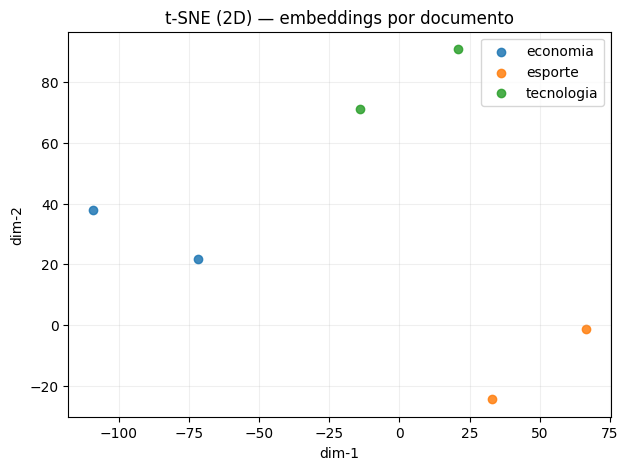

  doc_id       label
0     d1     esporte
1     d2     esporte
2     d3    economia
3     d4    economia
4     d5  tecnologia
5     d6  tecnologia


In [10]:
# Se necessário, descomente:
# !pip -q install -U sentence-transformers scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA
from sentence_transformers import SentenceTransformer

# ---------------------------------------
# 1) Dataset com 3 tópicos em português
# ---------------------------------------
docs = [
    {
        "id": "d1",
        "label": "esporte",
        "text": (
            "O time venceu por 2 a 1 no último minuto. "
            "O técnico elogiou a disciplina tática e a força do elenco. "
            "A torcida comemorou a classificação no estádio."
        )
    },
    {
        "id": "d2",
        "label": "esporte",
        "text": (
            "O campeonato começou com jogos equilibrados. "
            "O atacante marcou dois gols e foi o destaque da rodada. "
            "A equipe treinou finalizações durante a semana."
        )
    },
    {
        "id": "d3",
        "label": "economia",
        "text": (
            "A inflação desacelerou neste mês segundo o indicador oficial. "
            "O banco central sinalizou cautela na política monetária. "
            "O mercado reagiu com queda nos juros futuros."
        )
    },
    {
        "id": "d4",
        "label": "economia",
        "text": (
            "A taxa de câmbio variou após o anúncio do pacote fiscal. "
            "Analistas revisaram projeções de crescimento para o próximo ano. "
            "O consumo das famílias ainda mostra recuperação lenta."
        )
    },
    {
        "id": "d5",
        "label": "tecnologia",
        "text": (
            "Um novo modelo de linguagem foi lançado com foco em eficiência. "
            "Pesquisadores discutem alinhamento e segurança em inteligência artificial. "
            "O treinamento usou dados em múltiplos idiomas."
        )
    },
    {
        "id": "d6",
        "label": "tecnologia",
        "text": (
            "Sistemas de recomendação usam embeddings para medir similaridade. "
            "A compressão de modelos ajuda a reduzir custo de inferência. "
            "A comunidade debate benchmarks e avaliação justa."
        )
    },
]

# ---------------------------------------
# 2) Separar documentos em sentenças
# ---------------------------------------
def split_sentences_pt(text):
    partes = re.split(r'(?<=[\.\!\?])\s+', text.strip())
    return [p.strip() for p in partes if p.strip()]

rows = []
for d in docs:
    for sent in split_sentences_pt(d["text"]):
        rows.append({
            "doc_id": d["id"],
            "label": d["label"],
            "sentence": sent
        })

df_sents = pd.DataFrame(rows)

# ---------------------------------------
# 3) Carregar modelo encoder-only
# ---------------------------------------
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

# ---------------------------------------
# 4) Gerar embeddings por sentença
# ---------------------------------------
sentences = df_sents["sentence"].tolist()

emb = model.encode(
    sentences,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

df_sents = df_sents.copy()
df_sents["embedding"] = list(emb)

# ---------------------------------------
# 5) Redução de dimensionalidade
# ---------------------------------------
X = np.vstack(df_sents["embedding"].to_numpy())

X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X)
X_ica2 = FastICA(n_components=2, random_state=42, max_iter=2000).fit_transform(X)
X_tsne2 = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="pca",
    random_state=42
).fit_transform(X)

# ---------------------------------------
# 6) Função de plot
# ---------------------------------------
def plot_2d(X2, title, df_meta):
    plt.figure(figsize=(7, 5))
    for label, sub in df_meta.groupby("label"):
        idx = sub.index.to_numpy()
        plt.scatter(X2[idx, 0], X2[idx, 1], label=label, alpha=0.85)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_2d(X_pca2, "PCA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_ica2, "ICA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_tsne2, "t-SNE (2D) — embeddings de sentenças", df_sents)

# ---------------------------------------
# 7) Embedding por documento (média)
# ---------------------------------------
df_doc_emb = (
    df_sents
    .groupby(["doc_id", "label"])["embedding"]
    .apply(lambda vs: np.mean(np.vstack(vs), axis=0))
    .reset_index()
)

X_doc = np.vstack(df_doc_emb["embedding"].to_numpy())

X_doc_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_doc)
X_doc_tsne2 = TSNE(
    n_components=2,
    perplexity=3,
    learning_rate="auto",
    init="random",
    random_state=42
).fit_transform(X_doc)

plot_2d(X_doc_pca2, "PCA (2D) — embeddings por documento", df_doc_emb)
plot_2d(X_doc_tsne2, "t-SNE (2D) — embeddings por documento", df_doc_emb)

print(df_doc_emb[["doc_id", "label"]])

## Observações

A visualização mostrou que sentenças do mesmo tópico tendem a aparecer mais próximas, principalmente quando o conteúdo possui palavras e contexto bem relacionados. Em geral, os textos de **esporte**, **economia** e **tecnologia** apresentaram certa separação nos gráficos, embora nem sempre de forma perfeita, já que o conjunto de dados é pequeno.

No caso do **t-SNE**, a separação visual entre os grupos costuma ficar mais evidente, porque essa técnica preserva melhor relações locais entre os pontos. Já o **PCA** mostra uma visão mais global da variância dos dados, e por isso os agrupamentos podem parecer menos separados. O **ICA** também permite visualizar diferenças, mas normalmente é menos intuitivo para esse tipo de análise.

Quando os embeddings foram agregados por documento, a visualização ficou mais estável, pois a média das sentenças reduz ruídos e representa melhor o tema geral do documento.

## Conclusão

A atividade permitiu observar, na prática, como embeddings gerados por um modelo encoder-only podem representar o significado semântico de sentenças e documentos.

Com a redução de dimensionalidade, foi possível visualizar que textos semanticamente parecidos tendem a ocupar regiões próximas no espaço vetorial. Isso reforça a ideia de que embeddings são úteis para tarefas como agrupamento, busca semântica, recomendação e classificação de textos.

Assim, a prática ajudou a entender tanto a geração de embeddings quanto a interpretação visual dessas representações.